# 01 — Data Exploration

This notebook explores the EU AI Act PDF and the parsed graph data produced by the pipeline.

## Contents
1. Setup & Load Data
2. Raw PDF Text Inspection
3. Node Analysis
4. Edge Analysis
5. Graph Structure & Visualisation
6. Key Findings & Summary

---
## 1. Setup & Load Data

In [375]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import json
import yaml
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.manifold import TSNE
from collections import Counter
from pathlib import Path
import textwrap

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "configs").exists() and (REPO_ROOT / ".." / "configs").exists():
    REPO_ROOT = (REPO_ROOT / "..").resolve()


def resolve_path(path_str: str) -> Path:
    path = Path(path_str)
    if path.is_absolute():
        return path
    return REPO_ROOT / path

# Load config
with open(resolve_path("configs/config.yaml"), "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

matplotlib_cfg = config["visualization"]["matplotlib"]
plotly_cfg = config["visualization"]["plotly"]

# Style
sns.set_theme(
    style=matplotlib_cfg["seaborn_style"],
    palette=matplotlib_cfg["seaborn_palette"],
    font_scale=matplotlib_cfg["font_scale"],
)
plt.rcParams["figure.dpi"] = matplotlib_cfg["figure_dpi"]
plt.rcParams["figure.figsize"] = tuple(matplotlib_cfg["figure_size"])

PLOTLY_AXIS_COLOR = plotly_cfg["axis_color"]
PLOTLY_TITLE_COLOR = plotly_cfg["title_color"]
PLOTLY_SUBTITLE_COLOR = plotly_cfg["subtitle_color"]
PLOTLY_TEXT_COLOR = plotly_cfg["text_color"]
PLOTLY_GRID_COLOR = plotly_cfg["grid_color"]
PLOTLY_PAPER_BG = plotly_cfg["paper_bgcolor"]
PLOTLY_PLOT_BG = plotly_cfg["plot_bgcolor"]
PLOTLY_SEQUENCE = plotly_cfg["sequence"]
PLOTLY_CONTINUOUS_SCALE = plotly_cfg["continuous_scale"]
PLOTLY_HEATMAP_SCALE = plotly_cfg["heatmap_scale"]
PLOTLY_FONT_FAMILY = plotly_cfg.get("font_family", "Arial, sans-serif")


def title_case_label(value):
    return str(value).replace("_", " ").title()


def make_plotly_title(action_title, subtitle):
    title_wrapped = "<br>".join(textwrap.wrap(str(action_title), width=52))
    subtitle_wrapped = "<br>".join(textwrap.wrap(str(subtitle), width=72))
    return dict(
        text=(
            f"<span style='font-family:{PLOTLY_FONT_FAMILY};font-size:{plotly_cfg['title_font_size']}px;font-weight:bold;color:{PLOTLY_TITLE_COLOR};'>{title_wrapped}</span>"
            f"<br><span style='font-family:{PLOTLY_FONT_FAMILY};font-size:{plotly_cfg['subtitle_font_size']}px;font-weight: normal;color:{PLOTLY_SUBTITLE_COLOR};'>{subtitle_wrapped}</span>"
        ),
        x=0.01,
        xanchor="left",
        y=0.99,
        yanchor="top",
        pad=dict(t=plotly_cfg["title_pad_top"]),
    )


def apply_plotly_style(fig, action_title, subtitle, height=520, width=None, showlegend=False, horizontal_gridlines=False, footnote=None):
    base_margin = dict(plotly_cfg["margin"])
    # Guardrails to avoid clipped titles, tick labels, and footnotes across different figure types.
    base_margin["l"] = max(int(base_margin.get("l", 0)), 90)
    base_margin["r"] = max(int(base_margin.get("r", 0)), 40)
    base_margin["t"] = max(int(base_margin.get("t", 0)), 140)
    base_margin["b"] = max(int(base_margin.get("b", 0)), 120)
    if footnote:
        base_margin["b"] += 10

    fig.update_layout(
        template="plotly_white",
        title=make_plotly_title(action_title, subtitle),
        title_automargin=True,
        paper_bgcolor=PLOTLY_PAPER_BG,
        plot_bgcolor=PLOTLY_PLOT_BG,
        font={"family": PLOTLY_FONT_FAMILY, "size": plotly_cfg["base_font_size"], "color": PLOTLY_TEXT_COLOR},
        margin=base_margin,
        height=height,
        width=width,
        showlegend=showlegend,
        hoverlabel={
            "bgcolor": PLOTLY_PAPER_BG,
            "bordercolor": PLOTLY_AXIS_COLOR,
            "font": {"size": plotly_cfg["hover_font_size"], "color": PLOTLY_TEXT_COLOR},
        },
    )
    fig.update_xaxes(
        showline=True,
        linecolor=PLOTLY_AXIS_COLOR,
        linewidth=1,
        showgrid=False,
        zeroline=False,
        ticks="outside",
        automargin=True,
        title_standoff=10,
        title_font={"size": plotly_cfg["axis_title_font_size"], "color": PLOTLY_SUBTITLE_COLOR},
        tickfont={"size": plotly_cfg["axis_tick_font_size"], "color": PLOTLY_TEXT_COLOR},
    )
    fig.update_yaxes(
        showline=False,
        showgrid=horizontal_gridlines,
        gridcolor=PLOTLY_GRID_COLOR,
        gridwidth=plotly_cfg["grid_width"],
        zeroline=False,
        ticks="",
        automargin=True,
        title_standoff=10,
        title_font={"size": plotly_cfg["axis_title_font_size"], "color": PLOTLY_SUBTITLE_COLOR},
        tickfont={"size": plotly_cfg["axis_tick_font_size"], "color": PLOTLY_TEXT_COLOR},
    )
    fig.update_annotations(font={"size": plotly_cfg["footnote_font_size"], "color": PLOTLY_SUBTITLE_COLOR})
    fig.update_traces(cliponaxis=False, selector=dict(type="bar"))
    if footnote:
        fig.add_annotation(
            text=footnote,
            xref="paper",
            yref="paper",
            x=0,
            y=plotly_cfg["footnote_y"],
            xanchor="left",
            yanchor="top",
            showarrow=False,
            align="left",
            font={"size": plotly_cfg["footnote_font_size"], "color": plotly_cfg["footnote_color"]},
        )
    return fig


print("Config loaded ✓")



Config loaded ✓


In [376]:
# Load parsed text
with open(resolve_path(config['paths']['parsed_text']), "r", encoding="utf-8") as f:
    parsed_pages = json.load(f)

# Load nodes and edges
nodes_df = pd.read_csv(resolve_path(config['paths']['nodes_csv']))
edges_df = pd.read_csv(resolve_path(config['paths']['edges_csv']))

print(f"Parsed pages:  {len(parsed_pages)}")
print(f"Nodes:         {len(nodes_df)}")
print(f"Edges:         {len(edges_df)}")


Parsed pages:  144
Nodes:         974
Edges:         3873


---
## 2. Raw PDF Text Inspection

Let's look at the raw extracted text to understand the document structure.

In [377]:
# Basic document statistics
full_text = "\n\n".join(p["text"] for p in parsed_pages)
total_chars = len(full_text)
total_words = len(full_text.split())

page_lengths = [len(p["text"]) for p in parsed_pages]

print(f"Total characters:  {total_chars:,}")
print(f"Total words:       {total_words:,}")
print(f"Total pages:       {len(parsed_pages)}")
print(f"Avg chars/page:    {np.mean(page_lengths):,.0f}")
print(f"Min chars/page:    {np.min(page_lengths):,}")
print(f"Max chars/page:    {np.max(page_lengths):,}")


Total characters:  595,849
Total words:       91,421
Total pages:       144
Avg chars/page:    4,136
Min chars/page:    253
Max chars/page:    6,831


In [378]:
# Page length distribution
page_length_df = pd.DataFrame({
    "page_number": range(1, len(page_lengths) + 1),
    "characters": page_lengths,
})
mean_page_length = float(np.mean(page_lengths))

fig = px.bar(
    page_length_df,
    x="page_number",
    y="characters",
    color_discrete_sequence=[PLOTLY_SEQUENCE[1]],
)
fig.add_hline(
    y=mean_page_length,
    line_dash="dash",
    line_color=PLOTLY_SEQUENCE[15],
    annotation_text=f"Mean ({mean_page_length:.0f})",
    annotation_position="top left",
)
fig.update_traces(hovertemplate="Page %{x}<br>Characters: %{y}<extra></extra>")
fig.update_xaxes(title_text="Page Number", dtick=10)
fig.update_yaxes(title_text="Characters")
apply_plotly_style(
    fig,
    action_title="Tracking Page Length Reveals Uneven Document Density",
    subtitle="EU AI Act - Text Length per Page",
    height=520,
    horizontal_gridlines=True,
    footnote="Footnote: Bars show parsed character counts by PDF page; the dashed red line marks the mean page length.",
)
fig.show()





In [379]:
# Show sample text from different sections of the document
print("=" * 80)
print("SAMPLE: Page 1 (Title / Preamble)")
print("=" * 80)
print(parsed_pages[0]["text"][:500])

print("\n" + "=" * 80)
print("SAMPLE: Page 51 (Articles section)")
print("=" * 80)
print(parsed_pages[50]["text"][:500])


SAMPLE: Page 1 (Title / Preamble)
Official Journal EN
of the European Union L series
2024/1689 12.7.2024
REGULATION (EU) 2024/1689 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL
of 13 June 2024
laying down harmonised rules on artificial intelligence and amending Regulations (EC) No 300/2008,
(EU) No 167/2013, (EU) No 168/2013, (EU) 2018/858, (EU) 2018/1139 and (EU) 2019/2144 and
Directives 2014/90/EU, (EU) 2016/797 and (EU) 2020/1828 (Artificial Intelligence Act)
(Text with EEA relevance)
THE EUROPEAN PARLIAMENT AND THE COUNCIL O

SAMPLE: Page 51 (Articles section)
EN
OJ L, 12.7.2024
Article 4
AI literacy
Providers and deployers of AI systems shall take measures to ensure, to their best extent, a sufficient level of AI literacy of
their staff and other persons dealing with the operation and use of AI systems on their behalf, taking into account their
technical knowledge, experience, education and training and the context the AI systems are to be used in, and considering
the persons or g

---
## 3. Node Analysis

Examining the graph nodes extracted from the EU AI Act.

### Node Type Guide

The node types in this notebook correspond to sections of the EU AI Act PDF:

- `article`: a main legal provision such as `Article 5` or `Article 9` in the body of the regulation.
- `paragraph`: a numbered clause inside an article, typically the smaller legal units within that article.
- `recital`: a numbered introductory statement in the preamble before the articles begin. Recitals explain context and intent.
- `definition`: a clause defining a legal term, often phrased like `X means ...`.
- `annex`: a top-level annex section at the end of the regulation, such as `ANNEX I` or `ANNEX III`.
- `annex_item`: a smaller item or entry inside an annex, used to break annex content into retrievable chunks.


In [380]:
# Node overview
print("Node columns:", list(nodes_df.columns))
print()
nodes_df.head(10)

Node columns: ['node_id', 'title', 'type', 'text', 'page', 'article_number', 'chapter', 'annex', 'parent_id']



,node_id,title,type,text,page,article_number,chapter,annex,parent_id
0,recital_1,Recital (1),recital,(1) The purpose of this Regulation is to impro...,1,NaN,NaN,NaN,NaN
1,recital_2,Recital (2),recital,(2) This Regulation should be applied in accor...,1,NaN,NaN,NaN,NaN
2,recital_3,Recital (3),recital,(3) AI systems can be easily deployed in a lar...,1,NaN,NaN,NaN,NaN
3,recital_4,Recital (4),recital,(4) Position of the European Parliament of 13 ...,1,NaN,NaN,NaN,NaN
4,recital_5,Recital (5),recital,"(5) At the same time, depending on the circums...",2,NaN,NaN,NaN,NaN
5,recital_6,Recital (6),recital,(6) Given the major impact that AI can have on...,2,NaN,NaN,NaN,NaN
6,recital_7,Recital (7),recital,(7) In order to ensure a consistent and high l...,2,NaN,NaN,NaN,NaN
7,recital_8,Recital (8),recital,(8) A Union legal framework laying down harmon...,2,NaN,NaN,NaN,NaN
8,recital_9,Recital (9),recital,(9) Harmonised rules applicable to the placing...,3,NaN,NaN,NaN,NaN
9,recital_10,Recital (10),recital,(10) remain unaffected and fully applicable. F...,3,NaN,NaN,NaN,NaN


In [381]:
# Node type distribution
type_counts = nodes_df["type"].value_counts()
print("Node type distribution:")
print(type_counts)
print(f"\nTotal: {len(nodes_df)} nodes")

Node type distribution:
type
paragraph     500
recital       180
article       115
annex_item    100
definition     66
annex          13
Name: count, dtype: int64

Total: 974 nodes


In [382]:
# Node type bar chart (count only; no proportion chart)
type_count_df = type_counts.rename(index=title_case_label).reset_index()
type_count_df.columns = ["type_label", "count"]
colors = PLOTLY_SEQUENCE[:len(type_count_df)]
type_count_df = type_count_df.sort_values("count", ascending=True)

fig = go.Figure(
    data=[
        go.Bar(
            x=type_count_df["count"],
            y=type_count_df["type_label"],
            orientation="h",
            marker={"color": colors},
            text=type_count_df["count"],
            textposition="outside",
            hovertemplate="%{y}: %{x}<extra></extra>",
            showlegend=False,
        )
    ]
)
fig.update_xaxes(title_text="Count")
fig.update_yaxes(title_text="Node Type")
apply_plotly_style(
    fig,
    action_title="Comparing Node Types Shows Paragraphs Dominate The Graph",
    subtitle="Node Count By Type",
    height=560,
    horizontal_gridlines=False,
    footnote="Footnote: Bars show the number of nodes in each node type.",
)
fig.show()


In [383]:
# Text length analysis by node type
nodes_df["text_length"] = nodes_df["text"].str.len()
nodes_df["word_count"] = nodes_df["text"].str.split().str.len()

text_stats = nodes_df.groupby("type").agg(
    count=("text_length", "count"),
    mean_chars=("text_length", "mean"),
    median_chars=("text_length", "median"),
    max_chars=("text_length", "max"),
    mean_words=("word_count", "mean"),
).round(0)

print("Text length statistics by node type:")
text_stats

Text length statistics by node type:


,count,mean_chars,median_chars,max_chars,mean_words
type,,,,,
annex,13,3651.0,3196.0,8049,570.0
annex_item,100,425.0,210.0,4581,67.0
article,115,2622.0,1927.0,17380,404.0
definition,66,261.0,223.0,928,40.0
paragraph,500,517.0,384.0,4760,80.0
recital,180,1349.0,1080.0,5965,205.0


In [384]:
# Text length distribution by node type (box plot)
nodes_df_plot = nodes_df.copy()
nodes_df_plot["type_label"] = nodes_df_plot["type"].map(title_case_label)
order = nodes_df.groupby("type")["text_length"].median().sort_values(ascending=False).index.tolist()
order_labels = [title_case_label(value) for value in order]

fig = px.box(
    nodes_df_plot,
    x="type_label",
    y="text_length",
    category_orders={"type_label": order_labels},
    color="type_label",
    color_discrete_sequence=PLOTLY_SEQUENCE,
    points=False,
)
fig.update_layout(showlegend=False)
fig.update_xaxes(title_text="Node Type", tickangle=30)
fig.update_yaxes(title_text="Text Length (Characters)")
apply_plotly_style(
    fig,
    action_title="Comparing Node Text Lengths Reveals Definitions Stay Longest",
    subtitle="Text Length Distribution By Node Type",
    height=560,
    horizontal_gridlines=True,
    footnote="Footnote: Each box summarizes node text length by type, excluding outlier markers to keep category comparisons readable.",
)
fig.show()





In [385]:
# Chapter distribution (for articles and paragraphs)
chapter_nodes = nodes_df[nodes_df["type"].isin(["article", "paragraph"])].copy()
chapter_counts = chapter_nodes["chapter"].value_counts().sort_index()

# Roman numeral sort
roman_order = ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX", "X", "XI", "XII", "XIII"]
chapter_counts = chapter_counts.reindex(roman_order).dropna().astype(int)
chapter_df = chapter_counts.reset_index()
chapter_df.columns = ["chapter", "count"]

fig = px.bar(
    chapter_df,
    x="chapter",
    y="count",
    text="count",
    color="count",
    color_continuous_scale=PLOTLY_CONTINUOUS_SCALE,
)
fig.update_traces(textposition="outside", hovertemplate="Chapter %{x}<br>Nodes: %{y}<extra></extra>")
fig.update_layout(coloraxis_showscale=False)
fig.update_xaxes(title_text="Chapter", categoryorder="array", categoryarray=roman_order)
fig.update_yaxes(title_text="Number Of Nodes (Articles + Paragraphs)")
apply_plotly_style(
    fig,
    action_title="Mapping Chapters Shows Where Articles And Paragraphs Cluster",
    subtitle="Node Distribution Across Chapters",
    height=560,
    horizontal_gridlines=True,
    footnote="Footnote: Counts aggregate article and paragraph nodes by Roman-numeral chapter using the parsed graph metadata.",
)
fig.show()





In [386]:
# Articles with the most paragraphs
para_per_article = (
    nodes_df[nodes_df["type"] == "paragraph"]
    .groupby("article_number")
    .size()
    .sort_values(ascending=False)
)

print("Top 15 articles by number of paragraphs:")
top15 = para_per_article.head(15)
top15_df = top15.reset_index()
top15_df.columns = ["article_number", "paragraph_count"]
top15_df["article_number"] = top15_df["article_number"].astype(str)

fig = px.bar(
    top15_df,
    x="article_number",
    y="paragraph_count",
    text="paragraph_count",
    color_discrete_sequence=[PLOTLY_SEQUENCE[1]],
)
fig.update_traces(textposition="outside", hovertemplate="Article %{x}<br>Paragraphs: %{y}<extra></extra>")
fig.update_xaxes(title_text="Article Number")
fig.update_yaxes(title_text="Number Of Paragraphs")
apply_plotly_style(
    fig,
    action_title="Ranking Articles Highlights Where Paragraphs Concentrate",
    subtitle="Top 15 Articles By Paragraph Count",
    height=560,
    horizontal_gridlines=True,
    footnote="Footnote: Bars rank the 15 articles linked to the most paragraph nodes in the processed node table.",
)
fig.show()





Top 15 articles by number of paragraphs:


In [387]:
# Definitions overview
definitions = nodes_df[nodes_df["type"] == "definition"].copy()
definitions["term"] = definitions["title"].str.replace("Definition: ", "", regex=False)

print(f"Total definitions: {len(definitions)}")
print("\nAll defined terms:")
for i, term in enumerate(definitions["term"].values, 1):
    print(f"  ({i:2d}) {term}")


Total definitions: 66

All defined terms:
  ( 1) AI system
  ( 2) risk
  ( 3) provider
  ( 4) deployer
  ( 5) authorised representative
  ( 6) importer
  ( 7) distributor
  ( 8) operator
  ( 9) placing on the market
  (10) making available on the market
  (11) putting into service
  (12) intended purpose
  (13) reasonably foreseeable misuse
  (14) safety component
  (15) instructions for use
  (16) recall of an AI system
  (17) withdrawal of an AI system
  (18) performance of an AI system
  (19) notifying authority
  (20) conformity assessment
  (21) conformity assessment body
  (22) notified body
  (23) substantial modification
  (24) CE marking
  (25) post-market monitoring system
  (26) market surveillance authority
  (27) harmonised standard
  (28) common specification
  (29) training data
  (30) validation data
  (31) validation data set
  (32) testing data
  (33) input data
  (34) biometric data
  (35) biometric identification
  (36) biometric verification
  (37) special categori

---
## 4. Edge Analysis

Examining the relationships between nodes.

In [388]:
# Edge overview
print("Edge columns:", list(edges_df.columns))
print()
edges_df.head(10)


Edge columns: ['source', 'target', 'relation']



,source,target,relation
0,article_1,article_1_para_1,contains
1,article_1_para_1,article_1,part_of
2,article_1,article_1_para_2,contains
3,article_1_para_2,article_1,part_of
4,article_2,article_2_para_1,contains
5,article_2_para_1,article_2,part_of
6,article_2,article_2_para_2,contains
7,article_2_para_2,article_2,part_of
8,article_2,article_2_para_3,contains
9,article_2_para_3,article_2,part_of


In [389]:
# Edge type distribution (count only; no proportion chart)
relation_counts = edges_df["relation"].value_counts()
relation_df = relation_counts.rename(index=title_case_label).reset_index()
relation_df.columns = ["relation_label", "count"]
colors = PLOTLY_SEQUENCE[:len(relation_df)]
relation_df = relation_df.sort_values("count", ascending=True)

fig = go.Figure(
    data=[
        go.Bar(
            x=relation_df["count"],
            y=relation_df["relation_label"],
            orientation="h",
            marker={"color": colors},
            text=relation_df["count"],
            textposition="outside",
            hovertemplate="%{y}: %{x}<extra></extra>",
            showlegend=False,
        )
    ]
)
fig.update_xaxes(title_text="Count")
fig.update_yaxes(title_text="Relation Type")
apply_plotly_style(
    fig,
    action_title="Comparing Edge Types Shows References Drive Graph Connectivity",
    subtitle="Edge Count By Relation Type",
    height=560,
    horizontal_gridlines=False,
    footnote="Footnote: Bars show edge counts for each relation type in the graph.",
)
fig.show()

print()
print(f"Total edges: {len(edges_df)}")
print(f"Average edges per node: {len(edges_df) / len(nodes_df):.1f}")



Total edges: 3873
Average edges per node: 4.0


In [390]:
# Cross-reference analysis: which articles are most referenced?
refers_to_edges = edges_df[edges_df["relation"] == "refers_to"]

# Count incoming references per target
ref_target_counts = refers_to_edges["target"].value_counts().head(20)
ref_target_df = ref_target_counts.reset_index()
ref_target_df.columns = ["target", "incoming_references"]
ref_target_df["target_label"] = ref_target_df["target"].map(title_case_label)
ref_target_df = ref_target_df.sort_values("incoming_references", ascending=True)

fig = px.bar(
    ref_target_df,
    x="incoming_references",
    y="target_label",
    orientation="h",
    text="incoming_references",
    color_discrete_sequence=[PLOTLY_SEQUENCE[13]],
)
fig.update_traces(textposition="outside", hovertemplate="%{y}<br>Incoming References: %{x}<extra></extra>")
fig.update_xaxes(title_text="Number Of Incoming References")
fig.update_yaxes(title_text="Target Node")
apply_plotly_style(
    fig,
    action_title="Ranking Referenced Nodes Reveals Which Targets Attract The Most Links",
    subtitle="Top 20 Most Referenced Nodes (Refers_To)",
    height=720,
    footnote="Footnote: Horizontal bars rank the 20 most frequently targeted nodes under the refers_to relation.",
)
fig.show()



In [391]:
# Definition usage: which terms are used most frequently?
uses_term_edges = edges_df[edges_df["relation"] == "uses_term"]

# Map definition IDs to term names
def_id_to_term = dict(zip(
    nodes_df[nodes_df["type"] == "definition"]["node_id"],
    nodes_df[nodes_df["type"] == "definition"]["title"].str.replace("Definition: ", "", regex=False)
))

term_usage = uses_term_edges["target"].map(def_id_to_term).value_counts().head(20)
term_usage_df = term_usage.reset_index()
term_usage_df.columns = ["term", "usage_count"]
term_usage_df["term_label"] = term_usage_df["term"].map(title_case_label)
term_usage_df = term_usage_df.sort_values("usage_count", ascending=True)

fig = px.bar(
    term_usage_df,
    x="usage_count",
    y="term_label",
    orientation="h",
    text="usage_count",
    color_discrete_sequence=[PLOTLY_SEQUENCE[11]],
)
fig.update_traces(textposition="outside", hovertemplate="%{y}<br>Nodes Using Term: %{x}<extra></extra>")
fig.update_xaxes(title_text="Number Of Nodes Using This Term")
fig.update_yaxes(title_text="Defined Term")
apply_plotly_style(
    fig,
    action_title="Ranking Defined Terms Shows Which Concepts Recur Most Often",
    subtitle="Top 20 Most Frequently Used Defined Terms",
    height=720,
    footnote="Footnote: Bars count how often each defined term is targeted by uses_term edges across the graph.",
)
fig.show()



In [392]:
# Cross-reference heatmap between chapters
# Map nodes to chapters
node_to_chapter = dict(zip(nodes_df["node_id"], nodes_df["chapter"]))

# For refers_to edges, get source/target chapters
ref_edges = refers_to_edges.copy()
ref_edges["source_chapter"] = ref_edges["source"].map(node_to_chapter)
ref_edges["target_chapter"] = ref_edges["target"].map(node_to_chapter)

# Drop NaN chapters (recitals, annexes)
ref_edges = ref_edges.dropna(subset=["source_chapter", "target_chapter"])

roman_order = ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX", "X", "XI", "XII", "XIII"]

# Build bidirectional cross-reference matrix
cross_ref = pd.crosstab(
    ref_edges["source_chapter"], ref_edges["target_chapter"]
).reindex(index=roman_order, columns=roman_order, fill_value=0)
cross_ref = cross_ref.add(cross_ref.T, fill_value=0).astype(int)

fig = go.Figure(
    data=go.Heatmap(
        z=cross_ref.values,
        x=cross_ref.columns.tolist(),
        y=cross_ref.index.tolist(),
        colorscale=PLOTLY_HEATMAP_SCALE,
        text=cross_ref.values,
        texttemplate="%{text}",
        textfont={"color": PLOTLY_TEXT_COLOR},
        hovertemplate="Chapter %{y}<br>Chapter %{x}<br>Bidirectional References: %{z}<extra></extra>",
        colorbar={"title": "Bidirectional References", "tickfont": {"color": PLOTLY_TEXT_COLOR, "size": plotly_cfg["base_font_size"]}},
    )
)
fig.update_xaxes(title_text="Target Chapter", side="bottom")
fig.update_yaxes(title_text="Source Chapter")
apply_plotly_style(
    fig,
    action_title="Combining Chapter Pairs Reveals Where Cross-References Concentrate",
    subtitle="Bidirectional Cross-Reference Heatmap Between Chapters",
    height=760,
    footnote="Footnote: Matrix cells sum chapter-to-chapter references in both directions, so each pair is shown bidirectionally.",
)
fig.show()



---
## 5. Graph Structure & Visualisation

Build a NetworkX graph to analyse structural properties.

In [393]:
# Build NetworkX graph
G = nx.DiGraph()

for _, row in nodes_df.iterrows():
    G.add_node(row["node_id"], type=row["type"], article_number=row.get("article_number"))

for _, row in edges_df.iterrows():
    if row["source"] in G and row["target"] in G:
        G.add_edge(row["source"], row["target"], relation=row["relation"])

print(f"Graph nodes: {G.number_of_nodes()}")
print(f"Graph edges: {G.number_of_edges()}")
print(f"Density:     {nx.density(G):.4f}")
print(f"Is connected (weakly): {nx.is_weakly_connected(G)}")

components = list(nx.weakly_connected_components(G))
print(f"Weakly connected components: {len(components)}")
print(f"Largest component size: {max(len(c) for c in components)}")
print(f"Isolated nodes: {sum(1 for c in components if len(c) == 1)}")


Graph nodes: 954
Graph edges: 3837
Density:     0.0042
Is connected (weakly): False
Weakly connected components: 30
Largest component size: 925
Isolated nodes: 29


In [394]:
# Degree distribution
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {n: in_degrees[n] + out_degrees[n] for n in G.nodes()}

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("In-Degree Distribution", "Out-Degree Distribution", "Total Degree Distribution"),
)
fig.add_trace(
    go.Histogram(x=list(in_degrees.values()), nbinsx=30, marker={"color": PLOTLY_SEQUENCE[1]}, name="In-Degree", showlegend=False),
    row=1,
    col=1,
)
fig.add_trace(
    go.Histogram(x=list(out_degrees.values()), nbinsx=30, marker={"color": PLOTLY_SEQUENCE[13]}, name="Out-Degree", showlegend=False),
    row=1,
    col=2,
)
fig.add_trace(
    go.Histogram(x=list(total_degrees.values()), nbinsx=30, marker={"color": PLOTLY_SEQUENCE[11]}, name="Total Degree", showlegend=False),
    row=1,
    col=3,
)
fig.update_xaxes(title_text="In-Degree", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_xaxes(title_text="Out-Degree", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=2)
fig.update_xaxes(title_text="Total Degree", row=1, col=3)
fig.update_yaxes(title_text="Count", row=1, col=3)
apply_plotly_style(
    fig,
    action_title="Measuring Degree Distributions Reveals A Highly Skewed Network",
    subtitle="Degree Distribution",
    height=520,
    width=1300,
    horizontal_gridlines=True,
    footnote="Footnote: Histograms summarize in-degree, out-degree, and total degree across nodes in the directed graph.",
)
fig.show()

print(f"Average in-degree:    {np.mean(list(in_degrees.values())):.2f}")
print(f"Average out-degree:   {np.mean(list(out_degrees.values())):.2f}")
print(f"Average total degree: {np.mean(list(total_degrees.values())):.2f}")
print(f"Max total degree:     {max(total_degrees.values())}")





Average in-degree:    4.02
Average out-degree:   4.02
Average total degree: 8.04
Max total degree:     341


In [395]:
# Top nodes by degree (hub nodes)
degree_df = pd.DataFrame({
    "node_id": list(total_degrees.keys()),
    "total_degree": list(total_degrees.values()),
    "in_degree": [in_degrees[n] for n in total_degrees],
    "out_degree": [out_degrees[n] for n in total_degrees],
})
degree_df = degree_df.merge(nodes_df[["node_id", "type", "title"]], on="node_id", how="left")
degree_df = degree_df.sort_values("total_degree", ascending=False)

print("Top 20 nodes by total degree:")
degree_df.head(20)[["node_id", "type", "title", "in_degree", "out_degree", "total_degree"]]


Top 20 nodes by total degree:


,node_id,type,title,in_degree,out_degree,total_degree
796,definition_2,definition,Definition: risk,340,1,341
795,definition_1,definition,Definition: AI system,215,1,216
797,definition_3,definition,Definition: provider,173,1,174
182,article_3,article,Article 3: Definitions,78,73,151
814,definition_20,definition,Definition: conformity assessment,87,1,88
840,definition_47,definition,Definition: AI Office,85,1,86
861,annex_I,annex,Annex I: List of Union harmonisation legislation,53,21,74
883,annex_III,annex,Annex III: High-risk AI systems referred to in...,62,9,71
820,definition_26,definition,Definition: market surveillance authority,64,1,65
184,article_5,article,Article 5: Prohibited AI practices,38,23,61


In [396]:
# Degree by node type
degree_by_type = degree_df.groupby("type").agg(
    count=("total_degree", "count"),
    mean_degree=("total_degree", "mean"),
    max_degree=("total_degree", "max"),
    mean_in=("in_degree", "mean"),
    mean_out=("out_degree", "mean"),
).round(2)

print("Degree statistics by node type:")
degree_by_type.sort_values("mean_degree", ascending=False)

Degree statistics by node type:


,count,mean_degree,max_degree,mean_in,mean_out
type,,,,,
definition,66,28.36,341,27.21,1.15
annex,13,26.46,74,17.54,8.92
article,115,20.97,151,8.89,12.09
paragraph,500,4.93,27,1.46,3.47
recital,180,2.56,10,0.00,2.56
annex_item,100,2.37,5,1.00,1.37


Article subgraph: 113 nodes, 190 edges


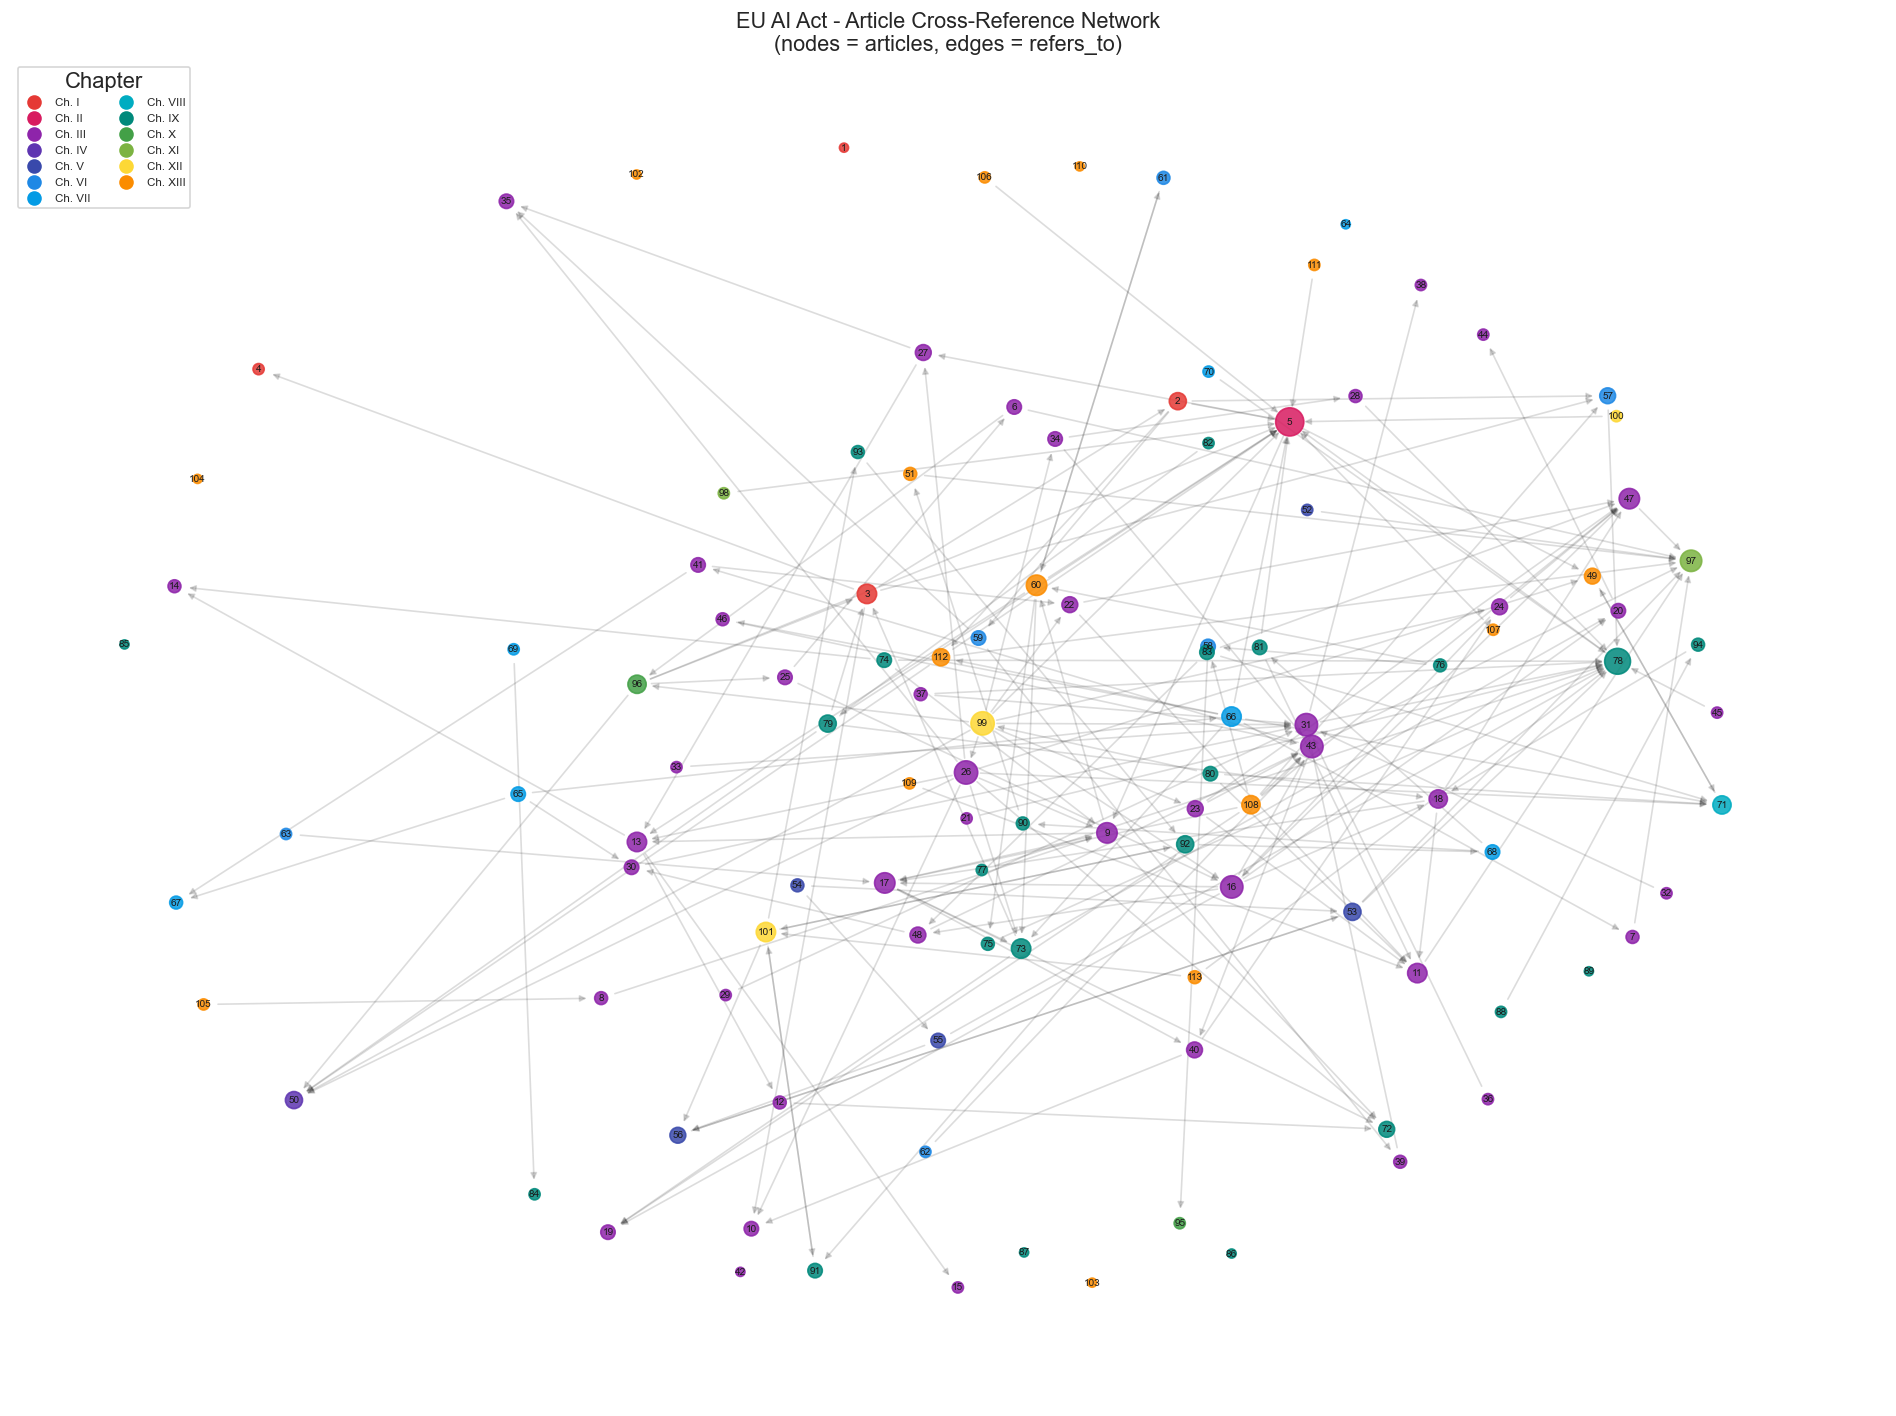

In [397]:
# Graph visualisation - article-level subgraph with cross-references
# (Full graph is too dense; show just articles + refers_to edges)

article_nodes = nodes_df[nodes_df["type"] == "article"]["node_id"].tolist()
article_refs = edges_df[
    (edges_df["relation"] == "refers_to") &
    (edges_df["source"].isin(article_nodes)) &
    (edges_df["target"].isin(article_nodes))
]

G_articles = nx.DiGraph()
for node_id in article_nodes:
    chapter = nodes_df[nodes_df["node_id"] == node_id]["chapter"].values[0]
    art_num = nodes_df[nodes_df["node_id"] == node_id]["article_number"].values[0]
    G_articles.add_node(node_id, chapter=chapter, art_num=int(art_num))

for _, row in article_refs.iterrows():
    G_articles.add_edge(row["source"], row["target"])

print(f"Article subgraph: {G_articles.number_of_nodes()} nodes, {G_articles.number_of_edges()} edges")

# Colour by chapter
chapter_colors = {
    "I": "#E53935", "II": "#D81B60", "III": "#8E24AA", "IV": "#5E35B1",
    "V": "#3949AB", "VI": "#1E88E5", "VII": "#039BE5", "VIII": "#00ACC1",
    "IX": "#00897B", "X": "#43A047", "XI": "#7CB342", "XII": "#FDD835",
    "XIII": "#FB8C00"
}

node_colors = [chapter_colors.get(G_articles.nodes[n].get("chapter", ""), "#999") for n in G_articles.nodes()]
node_sizes = [30 + G_articles.degree(n) * 15 for n in G_articles.nodes()]
labels = {n: str(G_articles.nodes[n]["art_num"]) for n in G_articles.nodes()}

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G_articles, k=0.8, iterations=80, seed=42)

nx.draw_networkx_edges(G_articles, pos, alpha=0.15, arrows=True, arrowsize=8, ax=ax)
nx.draw_networkx_nodes(G_articles, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G_articles, pos, labels, font_size=6, ax=ax)

# Legend
for ch, color in chapter_colors.items():
    ax.scatter([], [], c=color, s=60, label=f"Ch. {ch}")
ax.legend(loc="upper left", fontsize=7, ncol=2, title="Chapter")

ax.set_title("EU AI Act - Article Cross-Reference Network\n(nodes = articles, edges = refers_to)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()


In [398]:
# PageRank analysis - which nodes are most "important" structurally?
pagerank = nx.pagerank(G, alpha=0.85)
pr_df = pd.DataFrame({
    "node_id": list(pagerank.keys()),
    "pagerank": list(pagerank.values())
}).merge(nodes_df[["node_id", "type", "title"]], on="node_id", how="left")

pr_df = pr_df.sort_values("pagerank", ascending=False)

print("Top 20 nodes by PageRank:")
pr_df.head(20)[["node_id", "type", "title", "pagerank"]]


Top 20 nodes by PageRank:


,node_id,type,title,pagerank
182,article_3,article,Article 3: Definitions,0.258464
796,definition_2,definition,Definition: risk,0.027569
795,definition_1,definition,Definition: AI system,0.015639
861,annex_I,annex,Annex I: List of Union harmonisation legislation,0.015134
883,annex_III,annex,Annex III: High-risk AI systems referred to in...,0.013677
181,article_2,article,Article 2: Scope,0.011282
849,definition_56,definition,Definition: AI literacy,0.011114
797,definition_3,definition,Definition: provider,0.010777
840,definition_47,definition,Definition: AI Office,0.009167
237,article_57,article,Article 57: AI regulatory sandboxes,0.009024


In [399]:
# PageRank by node type
pr_df_plot = pr_df.copy()
pr_df_plot["type_label"] = pr_df_plot["type"].map(title_case_label)
pr_by_type = pr_df_plot.groupby("type_label")["pagerank"].mean().sort_values(ascending=False)
pr_by_type_df = pr_by_type.reset_index()
pr_by_type_df.columns = ["type_label", "mean_pagerank"]

fig = px.bar(
    pr_by_type_df,
    x="type_label",
    y="mean_pagerank",
    text="mean_pagerank",
    color="type_label",
    color_discrete_sequence=PLOTLY_SEQUENCE,
)
fig.update_traces(texttemplate="%{y:.4f}", textposition="outside")
fig.update_layout(showlegend=False)
fig.update_xaxes(title_text="Node Type", tickangle=30)
fig.update_yaxes(title_text="Mean PageRank")
apply_plotly_style(
    fig,
    action_title="Comparing Average PageRank Shows Which Node Types Carry The Most Influence",
    subtitle="Average PageRank By Node Type",
    height=560,
    horizontal_gridlines=True,
    footnote="Footnote: Bar heights show the mean PageRank score for each node type in the directed graph.",
)
fig.show()





In [400]:
# 3D t-SNE of vector embeddings
embedding_candidates = [
    ("GCN Embeddings", config["paths"].get("gcn_embeddings")),
    ("GNN Embeddings", config["paths"].get("gnn_embeddings")),
    ("Node Features", config["paths"].get("node_features")),
]

embedding_label = None
embedding_path = None
for label, candidate in embedding_candidates:
    if candidate and resolve_path(candidate).exists():
        embedding_label = label
        embedding_path = resolve_path(candidate)
        break

if embedding_path is None:
    raise FileNotFoundError("No embedding artifact was found for t-SNE visualisation.")

node_id_mapping_path = resolve_path(config["paths"]["node_id_mapping"])
with open(node_id_mapping_path, "r", encoding="utf-8") as f:
    node_id_mapping = json.load(f)

embeddings = np.load(embedding_path)
embedding_df = nodes_df[nodes_df["node_id"].isin(node_id_mapping)].copy()
embedding_df["embedding_idx"] = embedding_df["node_id"].map(node_id_mapping)
embedding_df = embedding_df.sort_values("embedding_idx").reset_index(drop=True)
embedding_matrix = embeddings[embedding_df["embedding_idx"].to_numpy()]

print(f"Running 3D t-SNE on {embedding_label.lower()}...")
perplexity = min(30, max(5, len(embedding_df) // 20))
tsne_3d = TSNE(n_components=3, perplexity=perplexity, random_state=42, init="pca", learning_rate="auto").fit_transform(embedding_matrix)

embedding_df["tsne_1"] = tsne_3d[:, 0]
embedding_df["tsne_2"] = tsne_3d[:, 1]
embedding_df["tsne_3"] = tsne_3d[:, 2]
embedding_df["type"] = embedding_df["type"].astype(str)
embedding_df["type_label"] = embedding_df["type"].map(title_case_label)
embedding_df["node_id"] = embedding_df["node_id"].astype(str)
embedding_df["chapter_label"] = embedding_df["chapter"].fillna("-").astype(str)
embedding_df["article_label"] = embedding_df["article_number"].fillna("-").astype(str)
embedding_df["annex_label"] = embedding_df["annex"].fillna("-").astype(str)
embedding_df["recital_label"] = embedding_df["title"].fillna("").astype(str).str.extract(r"Recital \((\d+)\)", expand=False).fillna("-")
embedding_df["reference_label"] = np.select(
    [
        embedding_df["type"].eq("article"),
        embedding_df["type"].eq("paragraph"),
        embedding_df["type"].eq("recital"),
        embedding_df["type"].eq("annex"),
        embedding_df["type"].eq("annex_item"),
        embedding_df["type"].eq("definition"),
    ],
    [
        "Article " + embedding_df["article_label"],
        "Article " + embedding_df["article_label"],
        "Recital " + embedding_df["recital_label"],
        "Annex " + embedding_df["annex_label"],
        "Annex " + embedding_df["annex_label"],
        embedding_df["title"].fillna("-").astype(str).map(title_case_label),
    ],
    default=embedding_df["title"].fillna("-").astype(str).map(title_case_label),
)

fig = px.scatter_3d(
    embedding_df,
    x="tsne_1",
    y="tsne_2",
    z="tsne_3",
    color="type_label",
    color_discrete_sequence=PLOTLY_SEQUENCE[4:15],
    custom_data=["reference_label", "type_label", "chapter_label", "article_label", "recital_label", "annex_label"],
)
fig.update_traces(
    marker={"size": 4, "opacity": 0.8},
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "Type: %{customdata[1]}<br>"
        "Chapter: %{customdata[2]}<br>"
        "Article: %{customdata[3]}<br>"
        "Recital: %{customdata[4]}<br>"
        "Annex: %{customdata[5]}<extra></extra>"
    ),
)
fig.update_layout(
    scene={
        "xaxis": {
            "title": {"text": "T-SNE 1", "font": {"size": 10, "color": PLOTLY_SUBTITLE_COLOR}},
            "showgrid": True,
            "gridcolor": PLOTLY_GRID_COLOR,
            "gridwidth": 0.6,
            "zeroline": False,
            "showbackground": True,
            "backgroundcolor": PLOTLY_PLOT_BG,
            "tickfont": {"size": 11, "color": PLOTLY_TEXT_COLOR},
        },
        "yaxis": {
            "title": {"text": "T-SNE 2", "font": {"size": 10, "color": PLOTLY_SUBTITLE_COLOR}},
            "showgrid": True,
            "gridcolor": PLOTLY_GRID_COLOR,
            "gridwidth": 0.6,
            "zeroline": False,
            "showbackground": True,
            "backgroundcolor": PLOTLY_PLOT_BG,
            "tickfont": {"size": 11, "color": PLOTLY_TEXT_COLOR},
        },
        "zaxis": {
            "title": {"text": "T-SNE 3", "font": {"size": 10, "color": PLOTLY_SUBTITLE_COLOR}},
            "showgrid": True,
            "gridcolor": PLOTLY_GRID_COLOR,
            "gridwidth": 0.6,
            "zeroline": False,
            "showbackground": True,
            "backgroundcolor": PLOTLY_PLOT_BG,
            "tickfont": {"size": 11, "color": PLOTLY_TEXT_COLOR},
        },
        "bgcolor": PLOTLY_PLOT_BG,
    },
    legend={"title": {"text": "Node Type", "font": {"size": 10, "color": PLOTLY_SUBTITLE_COLOR}}},
)
apply_plotly_style(
    fig,
    action_title="Projecting Embeddings Reveals Distinct Structural Clusters Across Node Types",
    subtitle=f"3D T-SNE Of {embedding_label} By Node Type",
    height=860,
    showlegend=True,
    footnote="Footnote: Points show a 3D t-SNE projection of the selected embedding vectors, colored by node type and annotated with structural metadata.",
)
fig.show()



Running 3D t-SNE on gcn embeddings...


---
## 6. Key Findings & Summary

In [401]:
# Summary statistics
print("=" * 60)
print("  EU AI Act Graph - Summary Statistics")
print("=" * 60)
print()
print(f"  Document:")
print(f"    Pages:              {len(parsed_pages)}")
print(f"    Words:              {total_words:,}")
print(f"    Characters:         {total_chars:,}")
print()
print(f"  Graph:")
print(f"    Total nodes:        {G.number_of_nodes()}")
print(f"    Total edges:        {G.number_of_edges()}")
print(f"    Density:            {nx.density(G):.4f}")
print(f"    Avg degree:         {np.mean(list(total_degrees.values())):.1f}")
print(f"    Components:         {len(components)}")
print()
print(f"  Nodes by type:")
for ntype, count in type_counts.items():
    print(f"    {ntype:20s} {count:5d}")
print()
print(f"  Edges by relation:")
for rel, count in relation_counts.items():
    print(f"    {rel:20s} {count:5d}")
print()
print(f"  Top 5 hub nodes (by degree):")
for _, row in degree_df.head(5).iterrows():
    print(f"    {row['title'][:50]:50s}  degree={row['total_degree']}")
print()
print("=" * 60)


  EU AI Act Graph - Summary Statistics

  Document:
    Pages:              144
    Words:              91,421
    Characters:         595,849

  Graph:
    Total nodes:        954
    Total edges:        3837
    Density:            0.0042
    Avg degree:         8.0
    Components:         30

  Nodes by type:
    paragraph              500
    recital                180
    article                115
    annex_item             100
    definition              66
    annex                   13

  Edges by relation:
    uses_term             1730
    refers_to              811
    contains               666
    part_of                666

  Top 5 hub nodes (by degree):
    Definition: risk                                    degree=341
    Definition: AI system                               degree=216
    Definition: provider                                degree=174
    Article 3: Definitions                              degree=151
    Definition: conformity assessment                 

### Key Observations

1. **Document Scale**: The EU AI Act is a substantial document spanning 144 pages with 113 articles across 13 chapters, plus 13 annexes and 180+ recitals.

2. **Graph Density**: The graph captures ~974 nodes and ~3,873 edges, giving a rich relational structure for the GNN to learn from.

3. **Edge Composition**: Definition usage edges (`uses_term`) are the most common, followed by cross-references (`refers_to`). This suggests that term propagation is a key structural feature of the legislation.

4. **Hub Nodes**: Certain articles (especially core definitional and high-risk system articles) are heavily referenced, making them natural hubs in the graph.

5. **Chapter III Dominance**: Chapter III (High-Risk AI Systems) contains the most articles and paragraphs, reflecting it as the legislative core.

6. **GNN Implications**: The heterogeneous edge types and varying node granularity (article → paragraph → definition) provide multi-scale structural signals for the GNN to exploit during retrieval.